# Compare computational and experimental results
 - peak pressure
    - and location
 - contact area
    - raw outputs
    - FEA adjusted to experimental resolution 
        - % overlap as well
 - displacement
 ---
 - Could compare across force range(10, 50+10, 10)
---
#### Study1
 - check it goes to 150N
#### Study2
 - runs to F = range(10, 50+10, 10)
 - Be good to figure out user defined refinement

# Experimental

In [73]:
import numpy as np
from pathlib import Path
import json
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt

from phd_helpers.experiments import get_sensor_loc, parse_tekscan, F2P, project_sensor, build_sensor_mesh
from phd_helpers.AbaqusPostprocessing import inp2pv, get_field_path, get_field_df, add_field_to_mesh, get_history_path

In [74]:
exp_path = Path('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/TekscanCalibration/20260317/test-tekscan/test1')
raw_files = list(exp_path.glob('*-raw.asm'))
raw_files

[PosixPath('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/TekscanCalibration/20260317/test-tekscan/test1/10N-raw.asm'),
 PosixPath('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/TekscanCalibration/20260317/test-tekscan/test1/50N-raw.asm'),
 PosixPath('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/TekscanCalibration/20260317/test-tekscan/test1/30N-raw.asm'),
 PosixPath('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/TekscanCalibration/20260317/test-tekscan/test1/40N-raw.asm'),
 PosixPath('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/TekscanCalibration/20260317/test-tekscan/test1/20N-raw.asm')]

In [75]:
tek_data = {} # {F1: imgP1, ...}
for raw_file in raw_files:
    F = int(raw_file.name.split('-')[0].split('N')[0])
    img = parse_tekscan(raw_file, 1)[0]
    imgP = F2P(img, F)[0] # convert from raw to pressure values using known F

    tek_data[F] = imgP

# FEA

In [76]:
fea_path = Path('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy')
inp_files = list(fea_path.glob('study2_*/**/*.inp'))
inp_files

[PosixPath('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study2_35T4d5/inpFiles/14548R/inp/35T-neutral-00/35T-neutral-00.inp'),
 PosixPath('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study2_35T4d5/inpFiles/14548R/inp/35T-neutral-01/35T-neutral-01.inp'),
 PosixPath('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study2_35T4d5/inpFiles/14548R/inp/35T-neutral-04/35T-neutral-04.inp'),
 PosixPath('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study2_35T4d5/inpFiles/14548R/inp/35T-neutral-03/35T-neutral-03.inp'),
 PosixPath('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study2_35T4d5/inpFiles/14548R/inp/35T-neutral-02/35T-neutral-02.inp')]

In [77]:
step, frame = 0, -1
field_metrics = ["CPRESS", "U"]
history_metrics = ['CAREA', 'RF']

fea_data = {} # {F1: {'tpm':mesh1, 'mc1':mesh1}, ...} - each mesh contains all fea data
for inp_file in inp_files:
    csv_dir = inp_file.parent / 'resultCSVs' 

    # get F
    run_id = inp_file.with_suffix('').name.split('-')[-1]
    param_path = fea_path / f'study2_35T4d5/params/loop_params/{run_id}.json'
    with open(param_path, 'r') as f:
        F = json.load(f)['_loop']['max_force']

    # get meshes
    meshes = inp2pv(inp_file)
    for bone, mesh in meshes.items():
        instance = f"{bone.upper()}_INST"
        
        # Field data
        for metric in field_metrics:
            field_path = get_field_path(csv_dir, metric, step, frame, instance)
            field_df = get_field_df(field_path)
            add_field_to_mesh(mesh, field_df)

        # History data
        history_data = pd.read_csv(get_history_path(csv_dir, step))
        # F
        RF_data = history_data[history_data['historyOutputKey']=='RF1']
        RF = np.abs(RF_data['value'].iloc[frame])
        # A
        CAREA_data = history_data[history_data['historyOutputDescription']=='Total area in contact']
        CA = CAREA_data['value'].iloc[frame]

        mesh.field_data['RF'] = RF
        mesh.field_data['CA'] = CA

        #Summary data
        mesh.field_data['P_max'] = mesh['CPRESS'].max()
        mesh.field_data['P_avg'] = np.mean(mesh['CPRESS'][mesh['CPRESS']>0])
        mesh.field_data['loc_Pmax'] = mesh.points[np.argmax(mesh['CPRESS'])]

    fea_data[F] = meshes

# Compare
 - Do contact area overlap % and Pmax location at some point

In [78]:
def find_boundary_cells(a):
    """Returns max of non-zero cells in an array that broder a zero"""
    a = np.asarray(a)
    m = a > 0
    out = np.zeros(a.shape, dtype=bool)

    out[1:, :]  |= m[1:, :]  & (a[:-1, :] == 0)
    out[:-1, :] |= m[:-1, :] & (a[1:, :] == 0)
    out[:, 1:]  |= m[:, 1:]  & (a[:, :-1] == 0)
    out[:, :-1] |= m[:, :-1] & (a[:, 1:] == 0)

    return out

def compute_img_metrics(img, sensel_area=1.6129):
    CA = len(img[img>0]) * sensel_area
    CA_e = find_boundary_cells(img).sum() * sensel_area # lower bound error bar for CA
    P_max = img.max()
    P_avg = img[img>0].mean()
    loc_Pmax = np.array(np.where(img==img.max())).ravel() # idx - (i, j)

    return {
        'CA': CA,
        'CA_e': CA_e,
        'P_max': P_max,
        'P_avg': P_avg,
        'loc_Pmax': loc_Pmax
    }

def compute_CA_overlap(img_fea, img_tek):
    mask_fea = (img_fea > 0)
    mask_tek = (img_tek > 0)
    CA_mean = (mask_fea.sum() + mask_tek.sum()) / 2
    CA_overlap = (mask_fea & mask_tek).sum()

    return 100-(100 * (CA_mean - CA_overlap) / CA_mean)

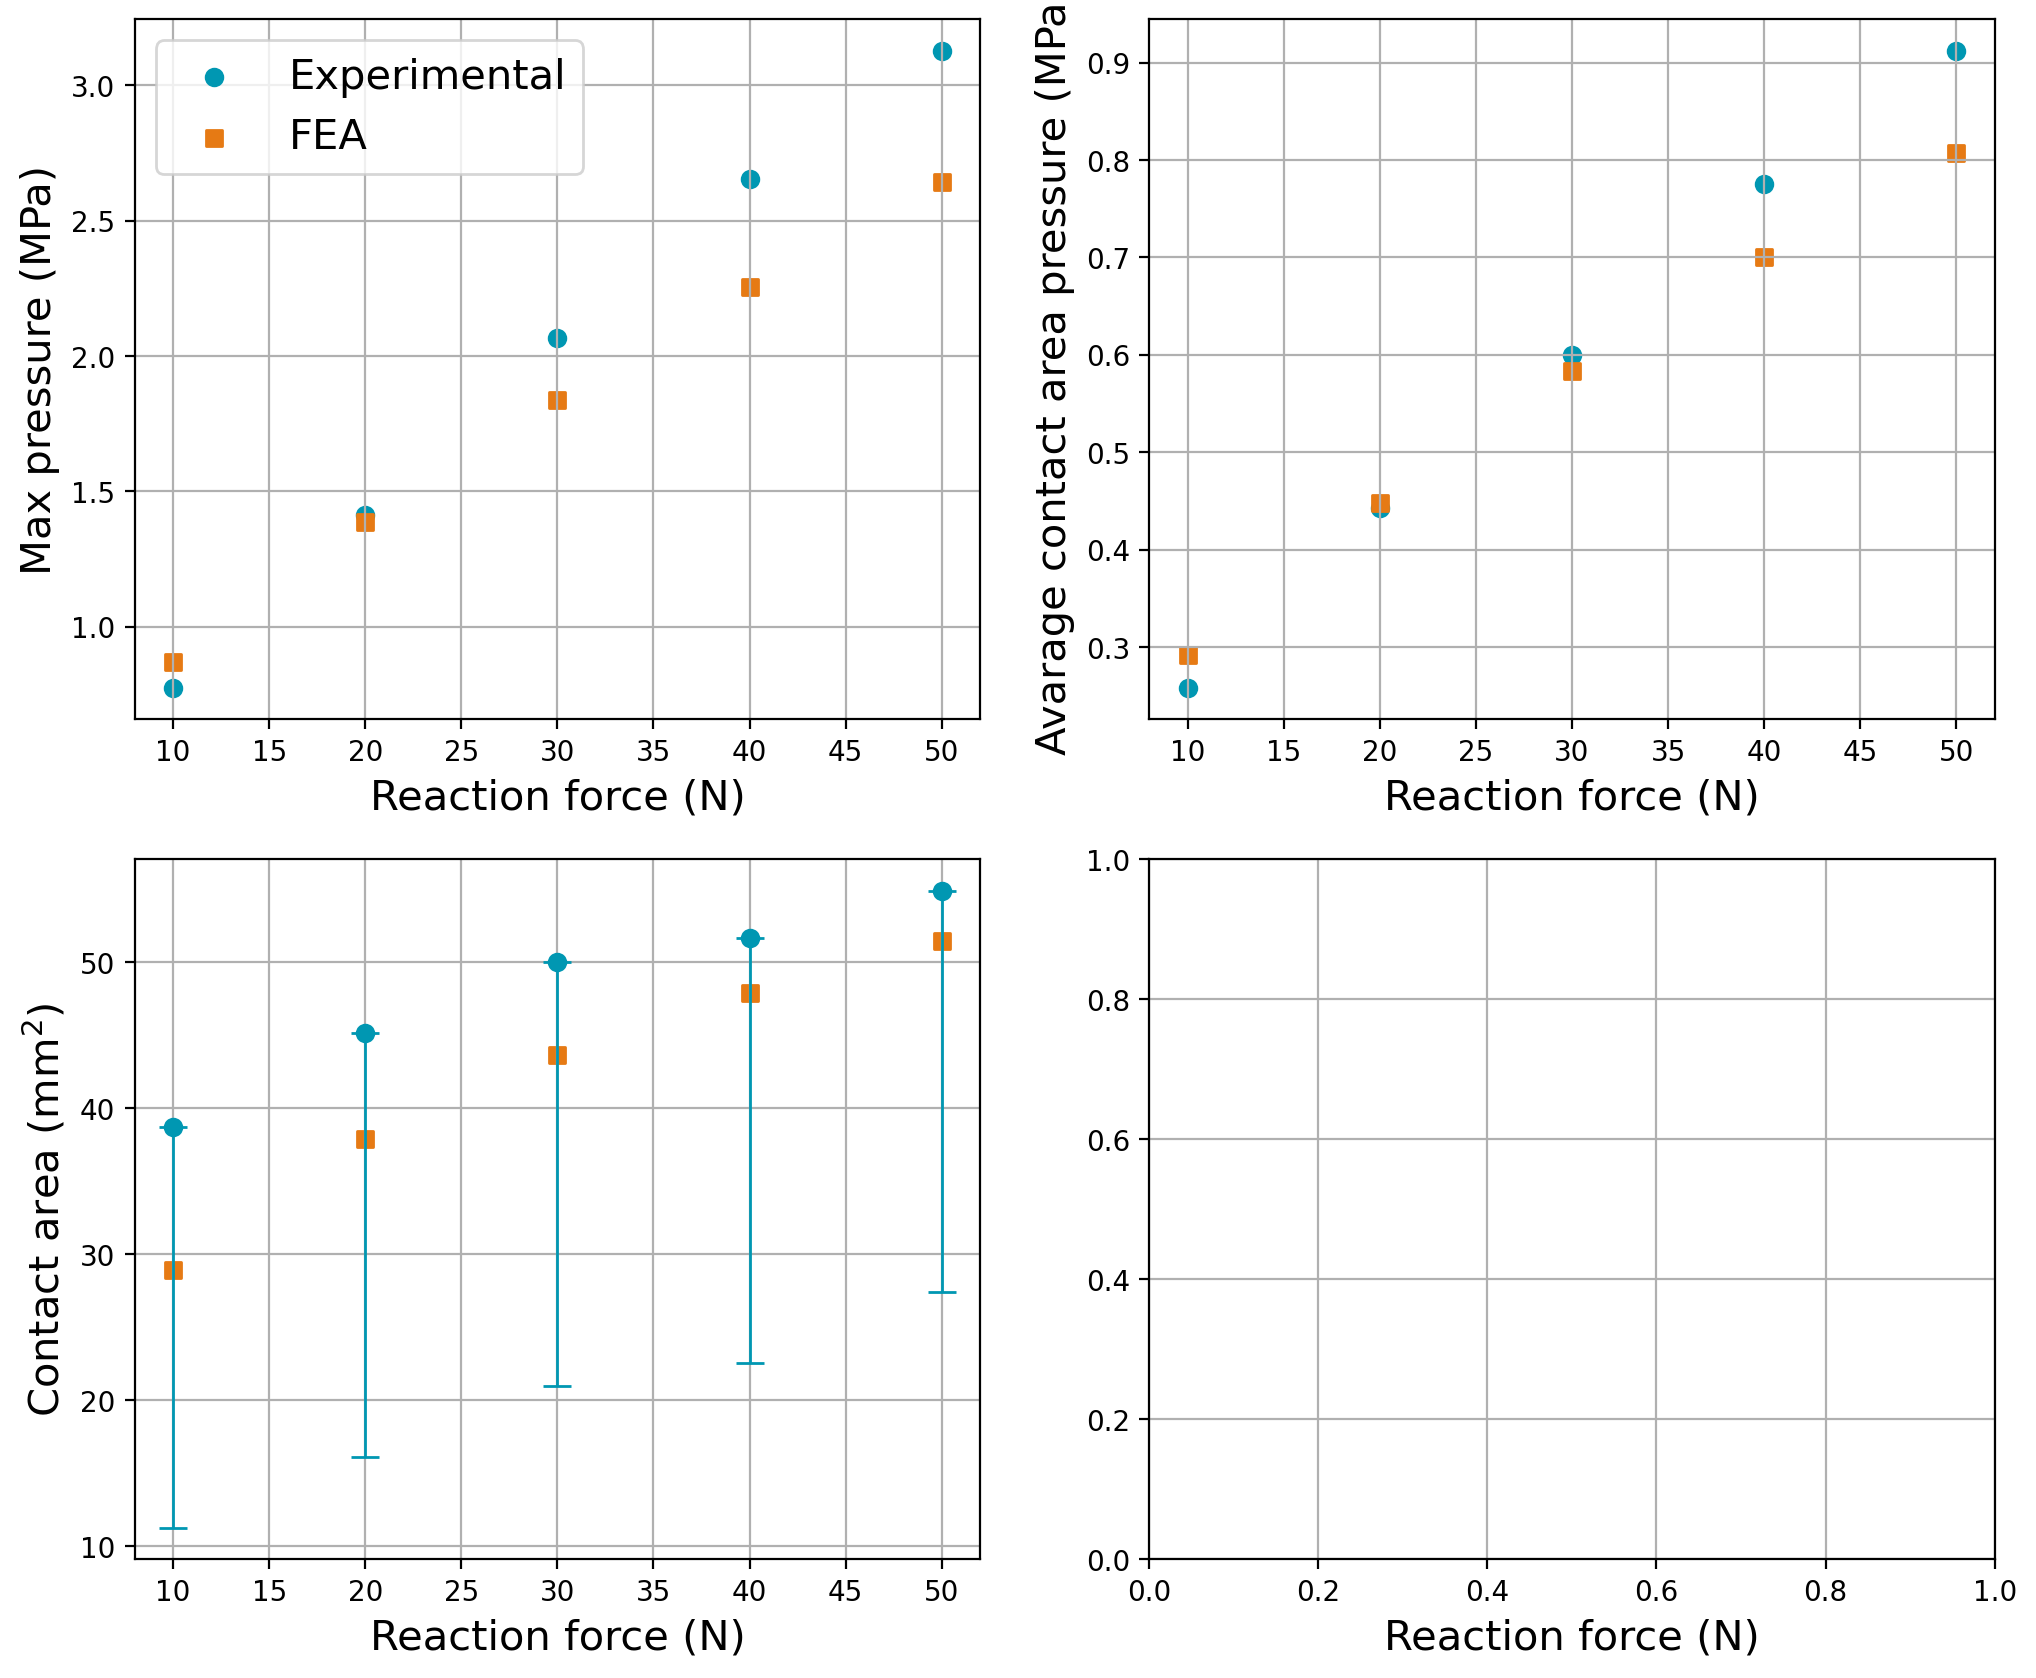

In [79]:
nrows, ncols = 2, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)
ax = ax.flatten()


fs = 15
colors = {
    "tek": "#0097b2",
         #"#009e73"
    "fea": "#e67a14"
         #"#cc79a7"
         #"#bfb200"
    }
markers = {
    "tek": "o",      # circle
    "fea": "s",    # square
}


Fs = sorted(tek_data.keys())
for F in Fs:
    tek_mets = compute_img_metrics(tek_data[F])
    mesh = fea_data[F]['tpm']

    label_tek = 'Experimental' if F==10 else None
    label_fea = 'FEA' if F==10 else None
    ax[0].scatter(F, tek_mets['P_max'], c=colors['tek'], marker=markers['tek'], label=label_tek)
    ax[0].scatter(F, mesh.field_data['P_max'], c=colors['fea'], marker=markers['fea'], label=label_fea)

    ax[1].scatter(F, tek_mets['P_avg'], c=colors['tek'], marker=markers['tek'])
    ax[1].scatter(F, mesh.field_data['P_avg'], c=colors['fea'], marker=markers['fea'])

    ax[2].errorbar(F, tek_mets['CA'], yerr=[[tek_mets['CA_e']], [0]] , c=colors['tek'], marker=markers['tek'], capsize=5, elinewidth=1)
    ax[2].scatter(F, mesh.field_data['CA'], c=colors['fea'], marker=markers['fea'])


ax[0].set_ylabel('Max pressure (MPa)', fontsize=fs)
ax[1].set_ylabel('Avarage contact area pressure (MPa)', fontsize=fs)
ax[2].set_ylabel('Contact area (mm$^2$)', fontsize=fs)
for ax_i in ax:
    ax_i.set_xlabel('Reaction force (N)', fontsize=fs)
    ax_i.grid()
ax[0].legend(fontsize=fs)
plt.show()

### FEA dowscaled to sensor grid

In [80]:
Fs = sorted(fea_data.keys())

fea_grid_data = {}
for F in Fs:
    sensor_loc = get_sensor_loc(fea_data[F]['mc1'], guide_wall_z=10, sensor_offset_z=-1, sensor_size=13.97) # skinny guide ledge
    sensor = build_sensor_mesh(sensor_loc, normal=(1, 0, 0), ncells=11, size=13.97)

    fea_grid = project_sensor(fea_data[F]['tpm'].copy(), sensor, img, data_loc='cells', 
                                downscale_fea=True, return_fea_grid=True, downscale_mode='max')
    
    fea_grid_data[F] = fea_grid

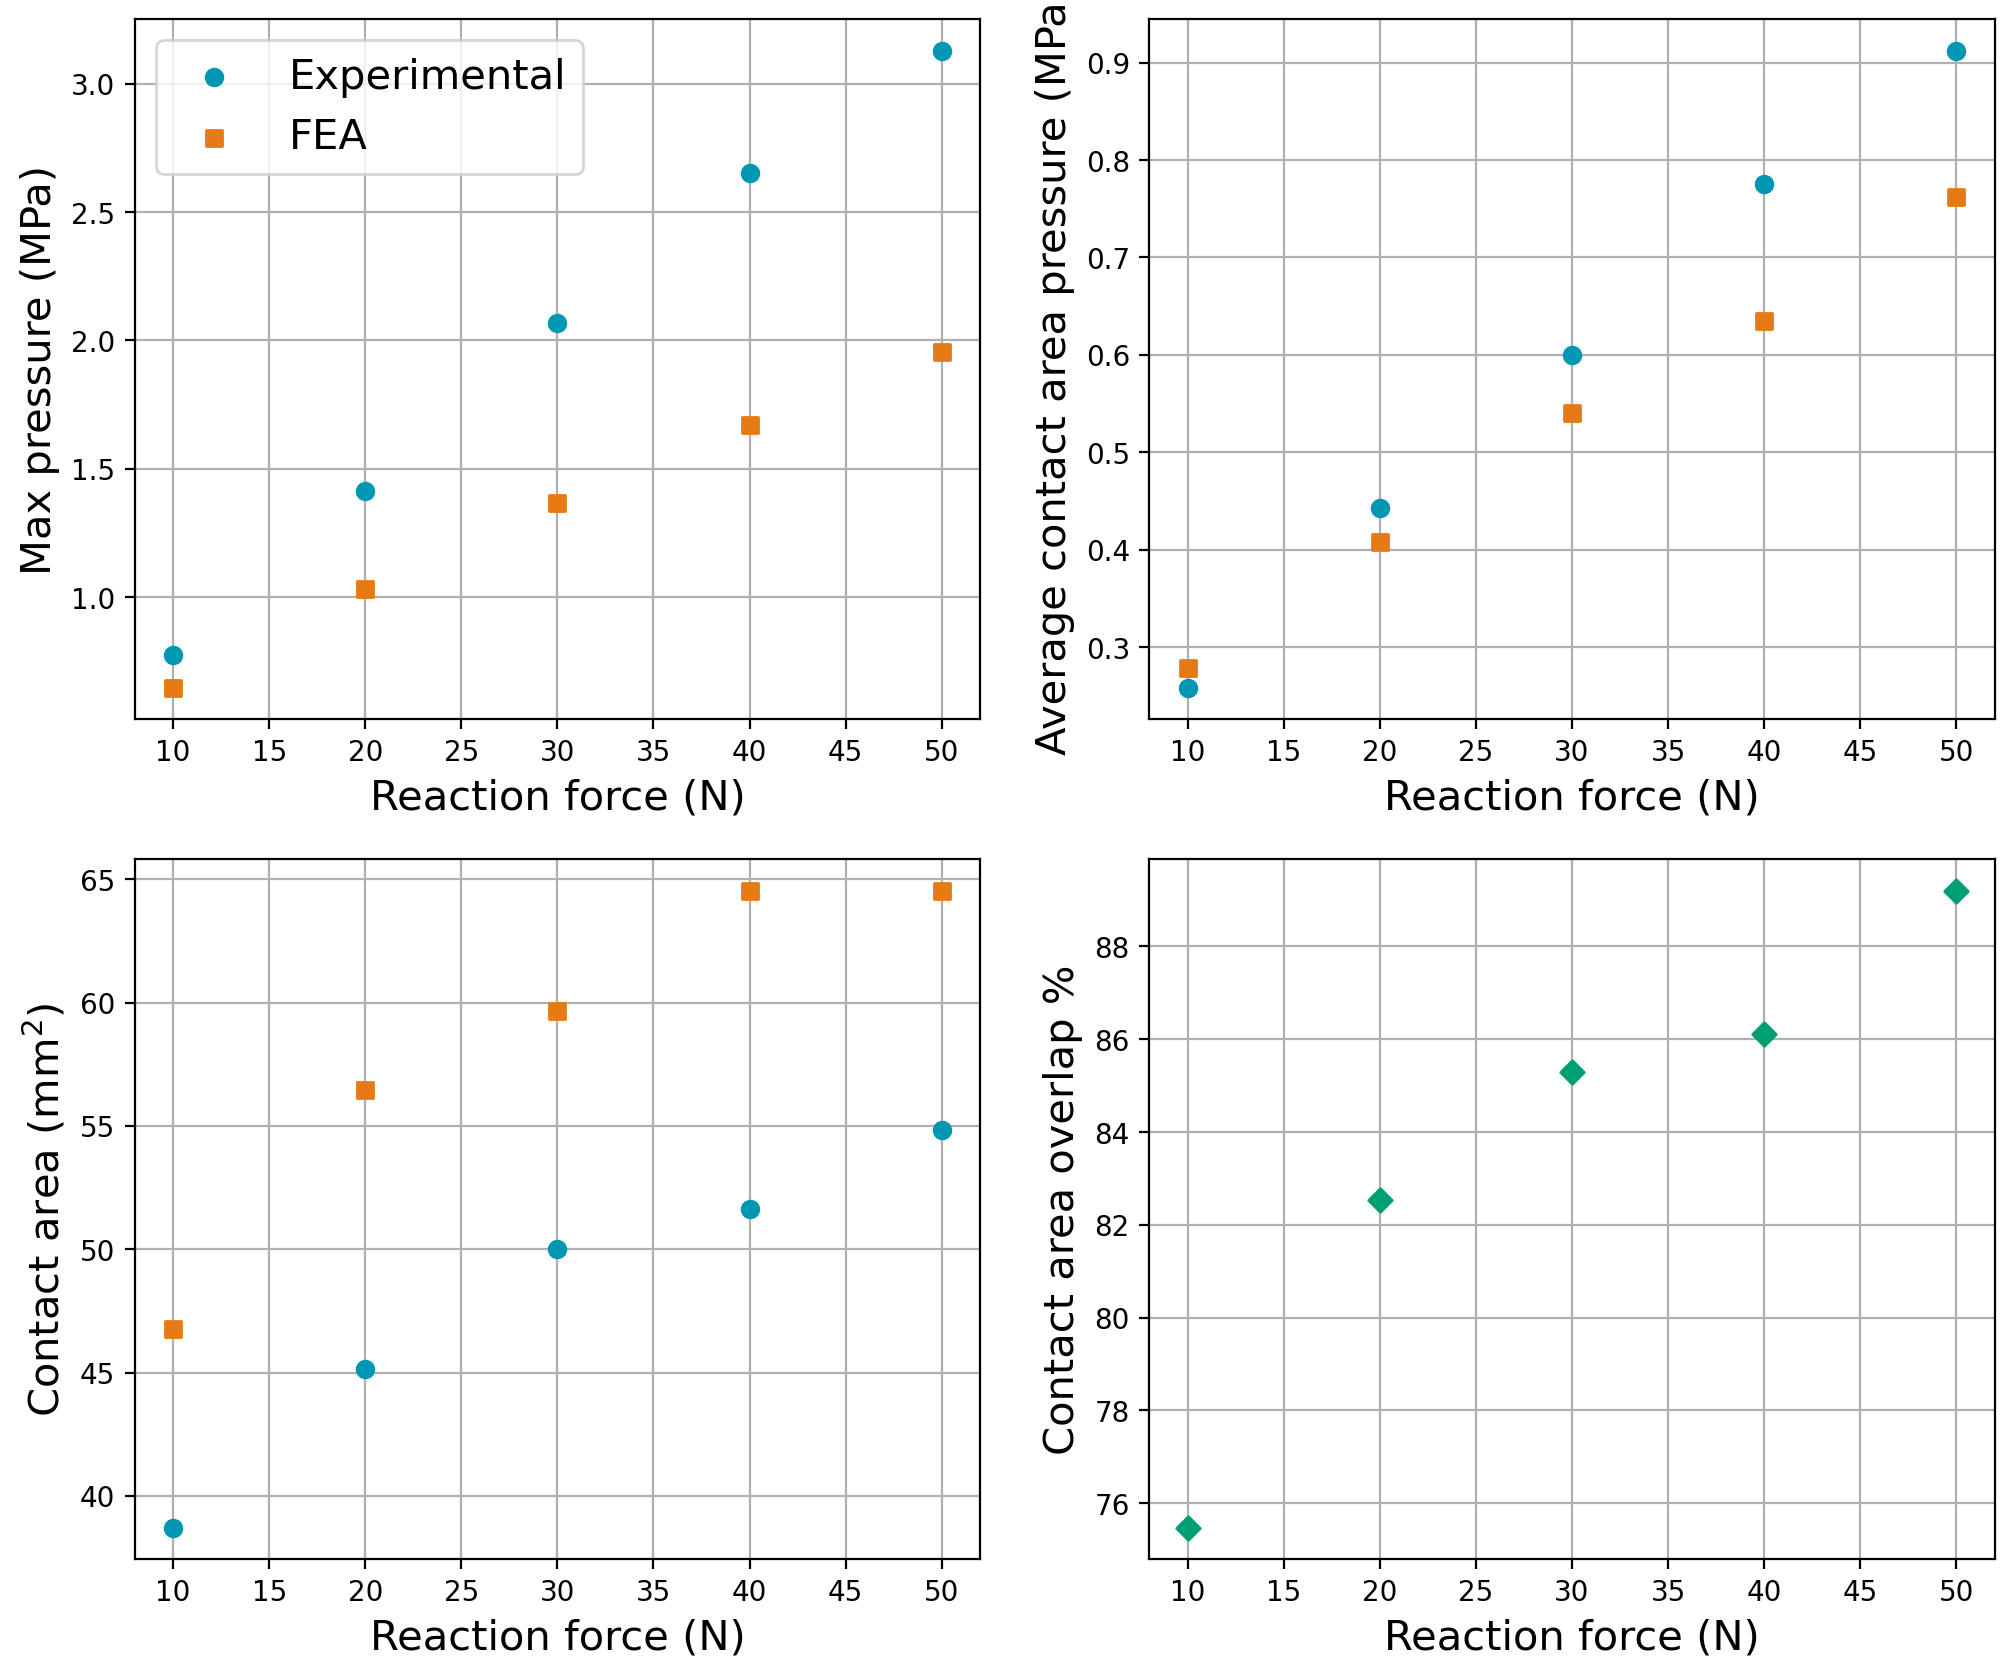

In [81]:
nrows, ncols = 2, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)
ax = ax.flatten()


fs = 15
colors = {
    "tek": "#0097b2",
         #"#009e73"
    "fea": "#e67a14"
         #"#cc79a7"
         #"#bfb200"
    }
markers = {
    "tek": "o",      # circle
    "fea": "s",    # square
}


Fs = sorted(tek_data.keys())
for F in Fs:
    tek_mets = compute_img_metrics(tek_data[F])
    fea_mets = compute_img_metrics(fea_grid_data[F])

    label_tek = 'Experimental' if F==10 else None
    label_fea = 'FEA' if F==10 else None
    ax[0].scatter(F, tek_mets['P_max'], c=colors['tek'], marker=markers['tek'], label=label_tek, zorder=2)
    ax[0].scatter(F, fea_mets['P_max'], c=colors['fea'], marker=markers['fea'], label=label_fea, zorder=2)

    ax[1].scatter(F, tek_mets['P_avg'], c=colors['tek'], marker=markers['tek'], zorder=2)
    ax[1].scatter(F, fea_mets['P_avg'], c=colors['fea'], marker=markers['fea'], zorder=2)

    ax[2].scatter(F, tek_mets['CA'], c=colors['tek'], marker=markers['tek'], zorder=2)
    ax[2].scatter(F, fea_mets['CA'], c=colors['fea'], marker=markers['fea'], zorder=2)

    ax[3].scatter(F, compute_CA_overlap(fea_grid_data[F], tek_data[F]), c="#009e73", marker="D", zorder=2)


ax[0].set_ylabel('Max pressure (MPa)', fontsize=fs)
ax[1].set_ylabel('Average contact area pressure (MPa)', fontsize=fs)
ax[2].set_ylabel('Contact area (mm$^2$)', fontsize=fs)
ax[3].set_ylabel('Contact area overlap %', fontsize=fs)
for ax_i in ax:
    ax_i.set_xlabel('Reaction force (N)', fontsize=fs)
    ax_i.grid()
ax[0].legend(fontsize=fs)
plt.show()

#### I think the contact area for FEA is exagerated because the tekscan sensels don't border each other, there is empty gaps so fea cells should only be active if traingle is close enough to centre of sensor grid cell.
 - Should also influence which value/s used for the grid cells max and mean values, only values close enough to centre should be involved
 - Need to refine that in project sensor function


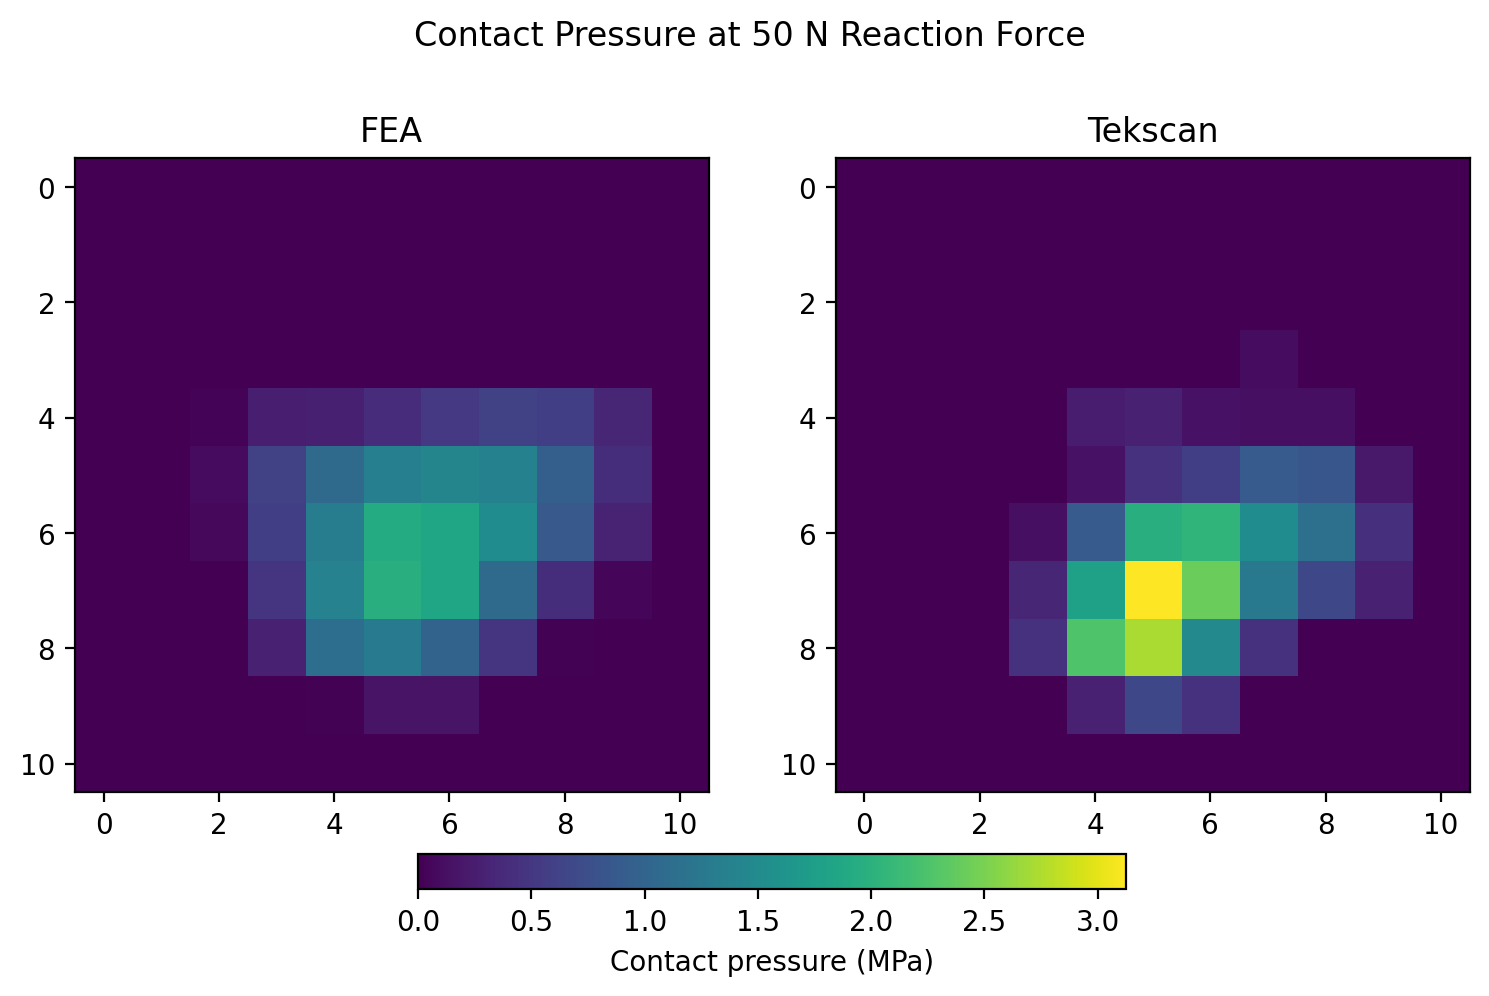

In [82]:
nrows, ncells = 1, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 5*nrows), dpi=200)

P_fea, P_tek = fea_grid_data[50], tek_data[50]

press_min = np.min( [np.min(P_fea), np.min(P_tek)] )
press_max = np.max( [np.max(P_fea), np.max(P_tek)] )
clims = (press_min, press_max)

im = ax[0].imshow(P_fea, vmin=clims[0], vmax=clims[1])
ax[1].imshow(P_tek, vmin=clims[0], vmax=clims[1])

ax[0].set_title('FEA')
ax[1].set_title('Tekscan')
fig.suptitle('Contact Pressure at 50 N Reaction Force')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.08, orientation='horizontal')
cbar.set_label('Contact pressure (MPa)')

plt.show()

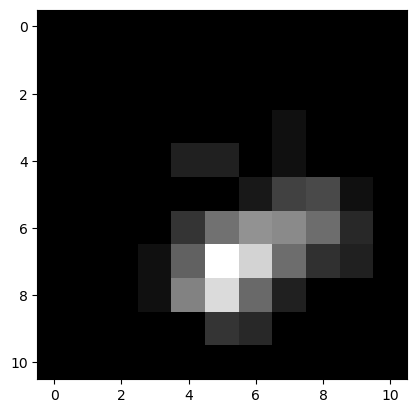

In [117]:
plt.imshow(img, cmap='gray')

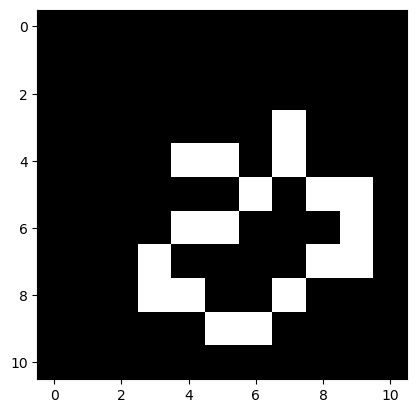

In [118]:
plt.imshow(find_boundary_cells(img), cmap='gray')